# Dimensionality reduction and data visualization


the idea is simple:
* map each high-dimensional vector to a single vector in a low-dimensional space

### Goals for today:
* get familiar with the concepts of dimensionality reduction and data visualiation
* see how tSNE works on simple data (3D->2D)
* see how it works on our mnist dataset (optionally fashion mnist)

tSNE (t-distributed stochastic neighbourhood embedding) to understand the the structure of the mnist (digits) dataset some more.
unsupervised learning method wihch will allow us to visualize the high-dimensional data in 2D (or 3D if we want)

### Technicalities

we use sklearn implementation of tSNE -- usage is very similar to k-means

today we will use:
* initialize model (setting some parameters)
* .fit function
* .embeddings_ (the result)
* we will normally use.fit_transorm function instead of the two steps above. it fits and returns the embedding in one go.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist, fashion_mnist
from sklearn.manifold import TSNE

# technicalities below
plt.rcParams["figure.figsize"] = (15,15) # larger default figures!

### 3D -> 2D intuition and technicalities
we'll generate some silly 3D data and then see how visualizing it in 2D works

##### dataset representation
dataet = matrix(N,D) 
- N = number of samples
- D = features

for example, 60_000 images, 784 pixels each

matrix -> X.shape = (60_000, 784)

we compute:

Y = f(X), where Y.shape (60_000, 2).

so every image becomes a 2D point

##### visualizing clusters
now you can plot:

plt.scatter(Y[:,0], Y[:,1])

if t-SNE works well:

you can see clusters:
cluster of 0s
cluster of 1s
cluster of 2s ...

Even though the algorithm never sal labels. 

**this is the unsupervised learning**

#### The ML Pipeline (conceptually)
1. load data set
2. flatten images
3. run t-sne
4. plot

**in other words,**

1. high dimensional dataset
2. computer pairwise similarity
3. optimize 2D coordinates
4. visualize clusters


### Data generation 

In [10]:
def generate_3d_blob(n, thinness=5):
    '''No need to read the implementations!'''
    X3 = np.random.randn(n, 3)
    ns = np.linalg.norm(X3, axis=1, keepdims=True)
    X3 /= ns
    X3 *= (1 + np.random.randn(n, 1)/thinness)
    return X3


def generate_vaguely_interesting_3D_data(n):
    '''
    Returns roughly n points in 3D in a vaguely interesting configuration.

    No need to read the implementation!
    '''
    num_extra = int(np.sqrt(n))
    blobs = [generate_3d_blob(n//3) + np.random.randn(3)*5 for _ in range(3)]
    extra = []
    for b1 in blobs:
        for b2 in blobs:
            c1 = np.mean(b1, axis=0)
            c2 = np.mean(b2, axis=0)
            extra.append(np.linspace(c1, c2, num_extra)
                         + np.random.randn(num_extra, 3)/3)

    return np.concatenate(blobs + extra)

### tSNE on synthetic 3D data

(np.float64(-10.855865574167048),
 np.float64(7.166517119508356),
 np.float64(-12.039071671823699),
 np.float64(5.983311021851705),
 np.float64(-4.980005914420778),
 np.float64(8.536781105835777))

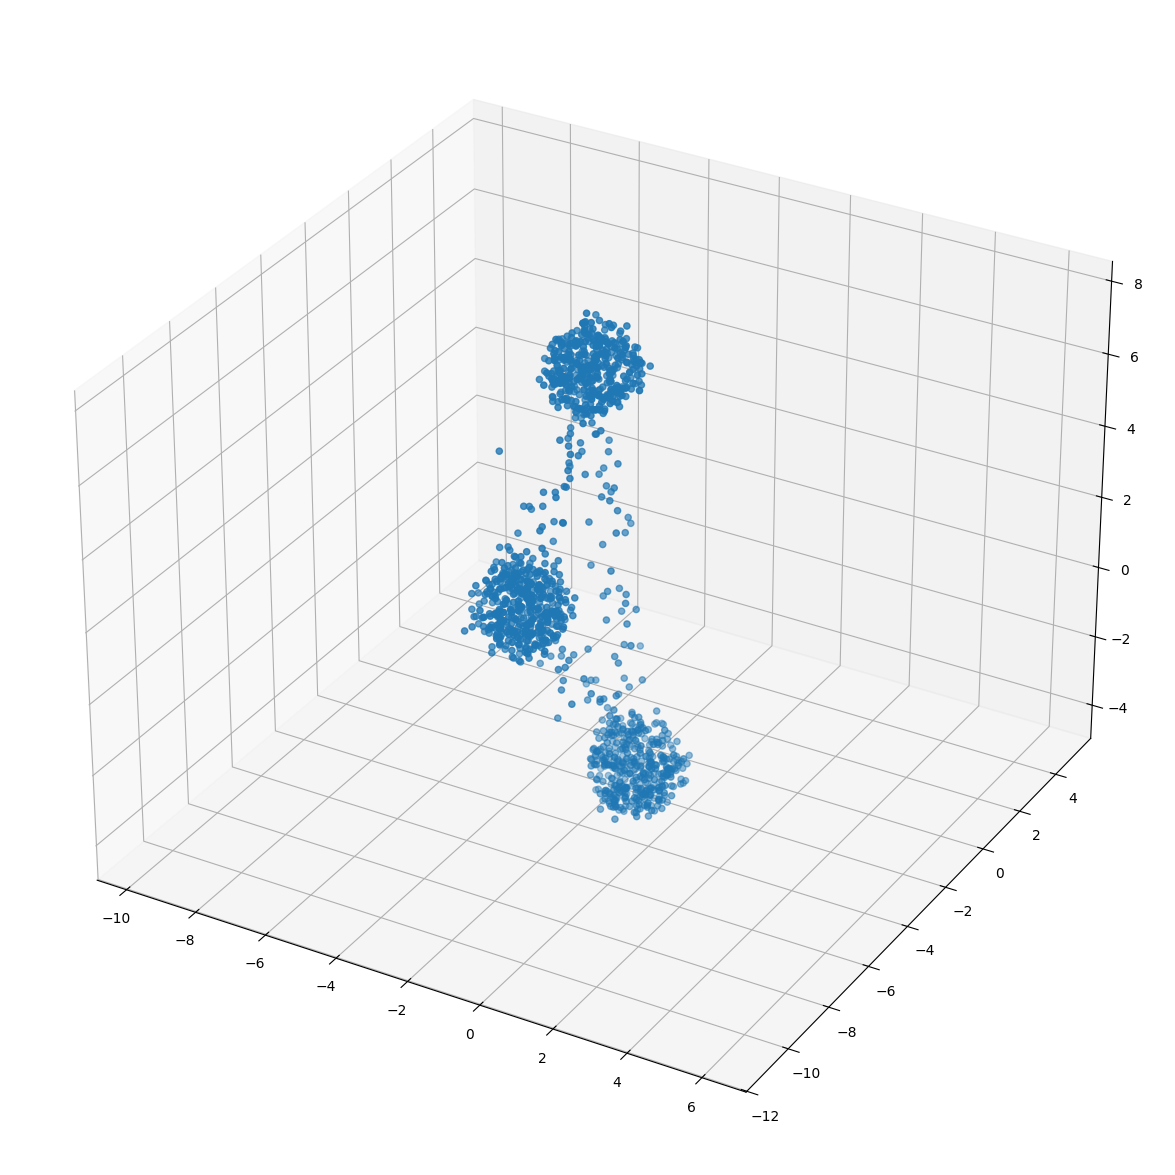

In [11]:
np.random.seed(5+1)
X3 = generate_vaguely_interesting_3D_data(1000)
ax = plt.axes(projection='3d')
ax.scatter3D(X3.T[0], X3.T[1], X3.T[2]) # we pass x, y, z now!
ax.axis('equal')

* (n_components=2) > target dimension is 2
* fit() > distance matrix, probabilities Pij
* transform() > optimize 2d coordinates

random initial points > gradient descent > minimize KL divergence


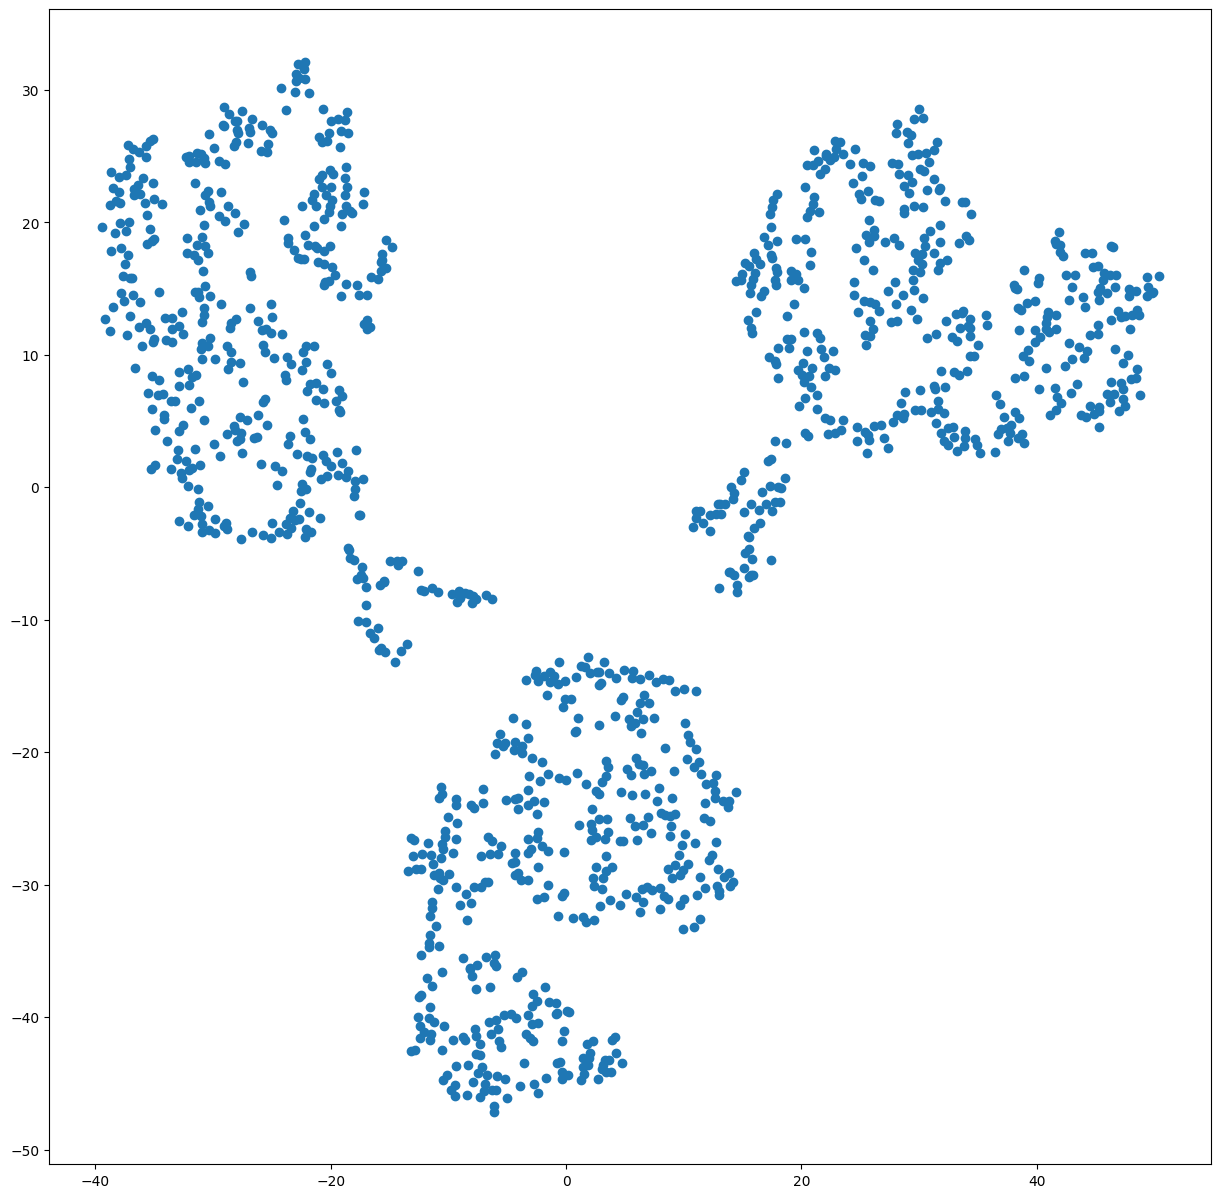

In [ ]:
tsne = TSNE(n_components=2)  # the 2 means we want to reduce the dimension to 2



X2 = tsne.fit_transform(X3)

# alternative, similar to how we used kMeans:
# tsne.fit(X3)
# X2 = tsne.embedding_

# now the i-th point of X2 is a 2d-vector representing the i-th vector in X3!
# so we can plot a 2d representation of our data
plt.scatter(X2.T[0], X2.T[1])

In [13]:
X3.shape, X2.shape

((1278, 3), (1278, 2))

### Important: tSNE is not a clustering method!

 You'll often see clusters, but (as you'll see later) it tends to overemphasise the existence of groups in the original dataset. In other words you'll often see disconnected groups of points -- this does not necessarily mean these were separate clusters in the original space!
 

### The Only Task
1. Fit tSNE with the mnist dataset (or fashion mnist if you prefer).
Like kMeans, it requires a 2D array as input. Hopefully you know what to do.

BTW: how many points can we reasonably handle? Let's start from only 2000.

2. Plot the resulting 2D embedding.
3. To verify the results scatter each resulting 2D points colored by its correct label.
4. Did it work?
Note that tSNE is an unsupervised learning algorithm -- but we use labels just to check how well it performed. We don't use the labels for fitting the tNSE model.

In [ ]:
# note that we fit tSNE only with x_train
# but y_train will be useful for verification

# 1. first you load the MNIST dataset
(x_train, y_train), _ = mnist.load_data()

x_train.shape, y_train.shape

# 60_000 images, each image = 28x28 pixels, each label = 0-9 digits

((60000, 28, 28), (60000,))

In [19]:
# 2. then limit the dataset size.

NUM_VECTORS = 2000  # PARAM

# 3. slice the dataset 
x_train = x_train[:NUM_VECTORS]/255.
y_train = y_train[:NUM_VECTORS]

In [21]:
x_train.shape, y_train.shape # now 2000 samples!

((2000, 28, 28), (2000,))

In [22]:
#4. t-SNE requires a 2D array input (n_samples, n_features) so must flatten each image
x_train = x_train.reshape(NUM_VECTORS, -1)

In [24]:
x_train.shape # now flatten!

(2000, 784)

In [39]:
# 5. now initialize t-SNE

num_iters = 250 # PARAM <- controls speed vs accuracy
perplexity = 5 # PARAM <- larget means more neighbours are taken into account
# it's related to the number of neighbours considered, but not exactly this number
# we'll discuss it later!

my_random_state = 1236  # PARAM <- just makes sure we all see same stuff

# init tsne (this defines the algorithm)
tsne = TSNE(n_components=2, max_iter=num_iters, perplexity=perplexity, random_state=my_random_state)

In [40]:
# 6. fit the model - similarly to k-means

x_reduced = tsne.fit_transform(x_train)


#### this performs:
1. compute pairwise similarities
2. build probability matrix P
3. intialize random 2d coordinates
4. run gradient descent
5. return final coordinates

In [41]:
x_reduced.shape

(2000, 2)

In [42]:
assert x_reduced.shape == (2000, 2) # 2000 Points and 2 dimensions

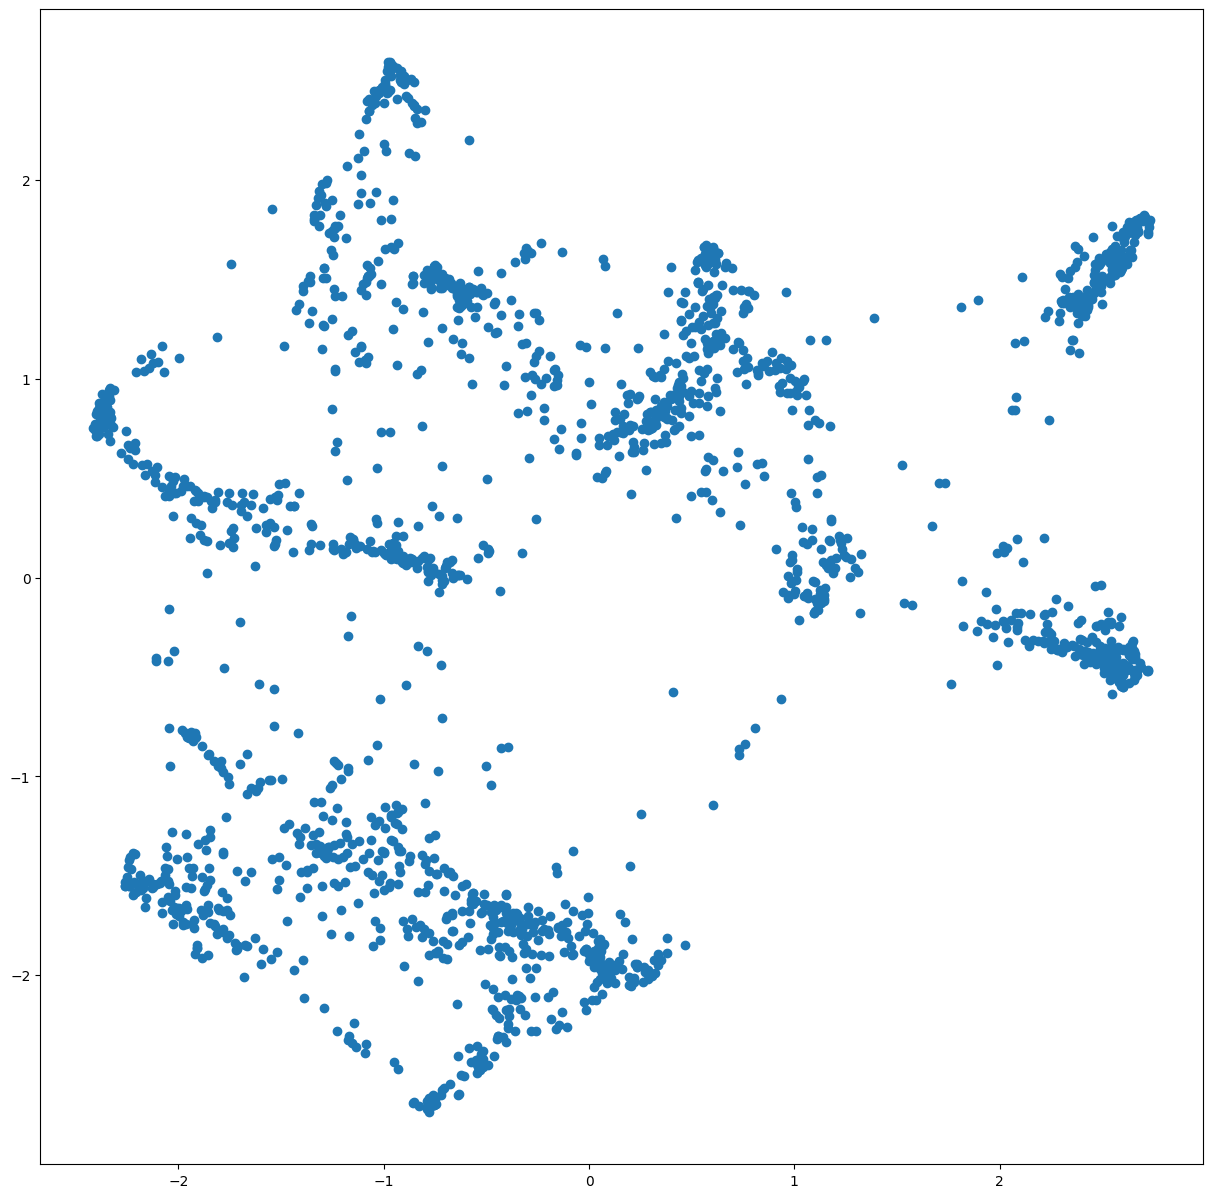

In [43]:
plt.scatter(x_reduced.T[0], x_reduced.T[1])

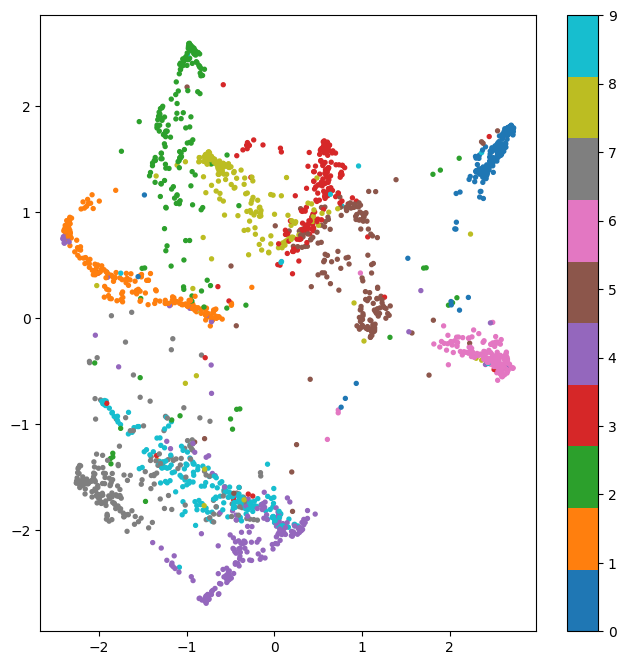

In [44]:
plt.figure(figsize=(8,8))
plt.scatter(x_reduced[:,0], x_reduced[:,1], c=y_train, s=8, cmap="tab10")
plt.colorbar()
plt.show()

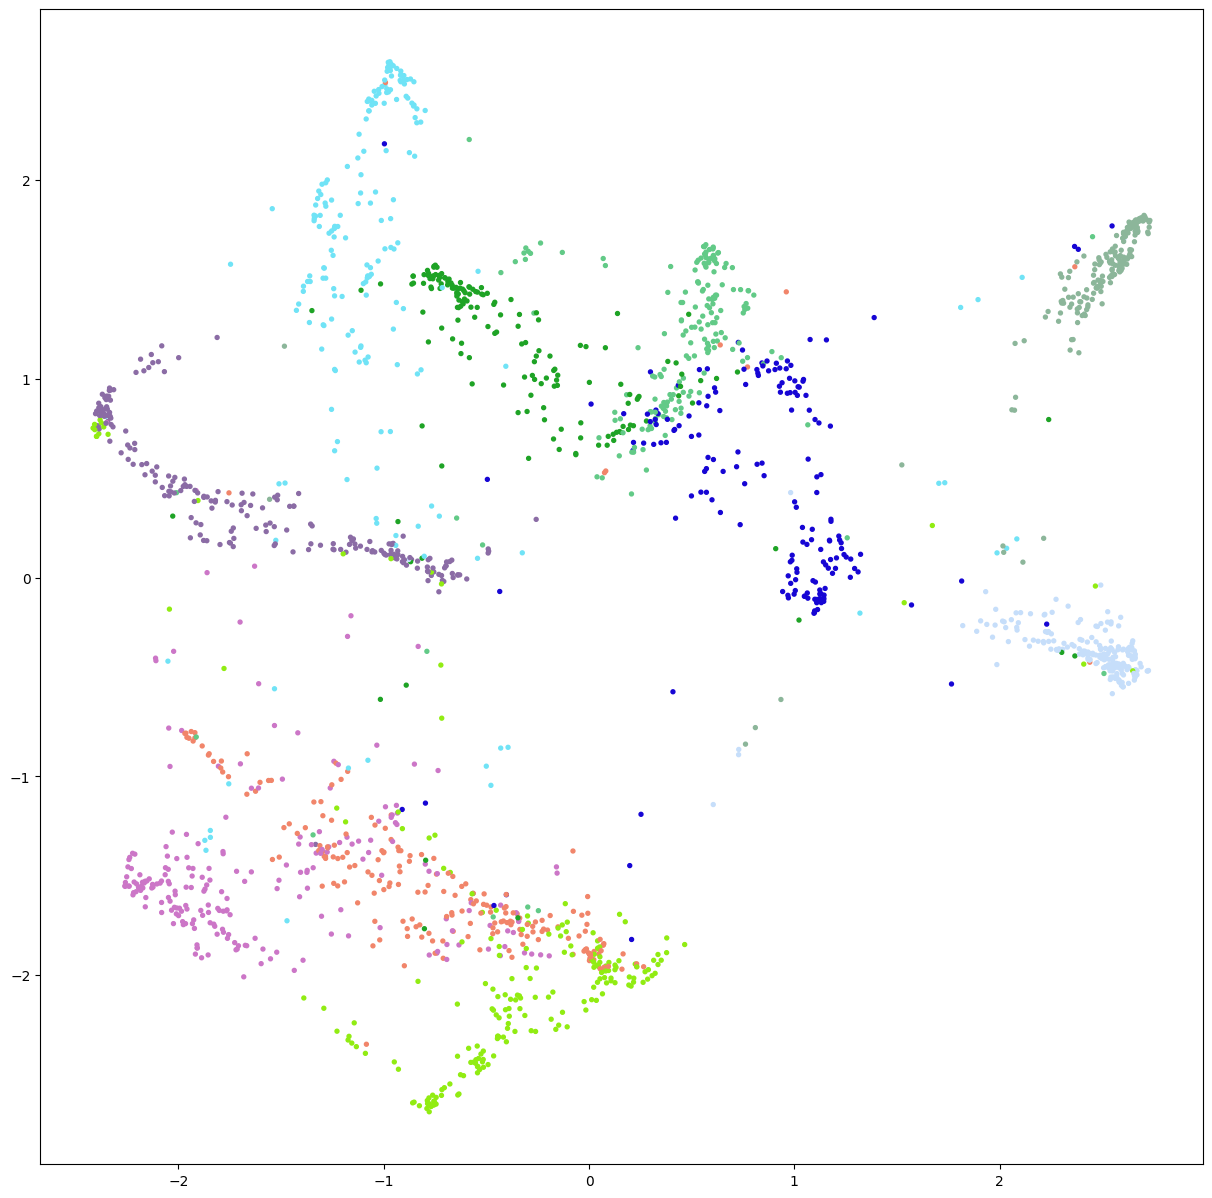

In [47]:
np.random.seed(0)

label_colors = np.random.random((10, 3))  # some random colors (RGB vectors!)
# now we have a colors baed on labels; it can be used with plt.scatter(..., c=?)
point_colors = label_colors[y_train]

# scatter the points with colors
plt.scatter(x_reduced[:,0], x_reduced[:,1], c=point_colors, s=8)
plt.show()

In [62]:
# x_train_img = x_train
# x_train_flat = x_train.reshape(NUM_VECTORS, -1)
# x_reduced = tsne.fit_transform(x_train_flat)

# print(x_train_img.shape, x_train_flat.shape, x_reduced.shape)

# x_train_img = x_train_original[:NUM_VECTORS] / 255.0
# x_train_flat = x_train_img.reshape(NUM_VECTORS, -1)

In [65]:
# DON'T LOOK AT THE IMPLEMENTATION, it's just technicalities
from matplotlib.offsetbox import OffsetImage, AnnotationBbox


def plot_image_at_point(im, xy, zoom=1):
    '''
    Plots a tiny image at point xy.
    '''
    dxy = np.random.rand(2)/100 * plt.ylim()
    plt.arrow(*xy, *dxy)
    ab = AnnotationBbox(OffsetImage(im, zoom=zoom, cmap='gray_r'),
                        xy + dxy, frameon=False)
    plt.gca().add_artist(ab)

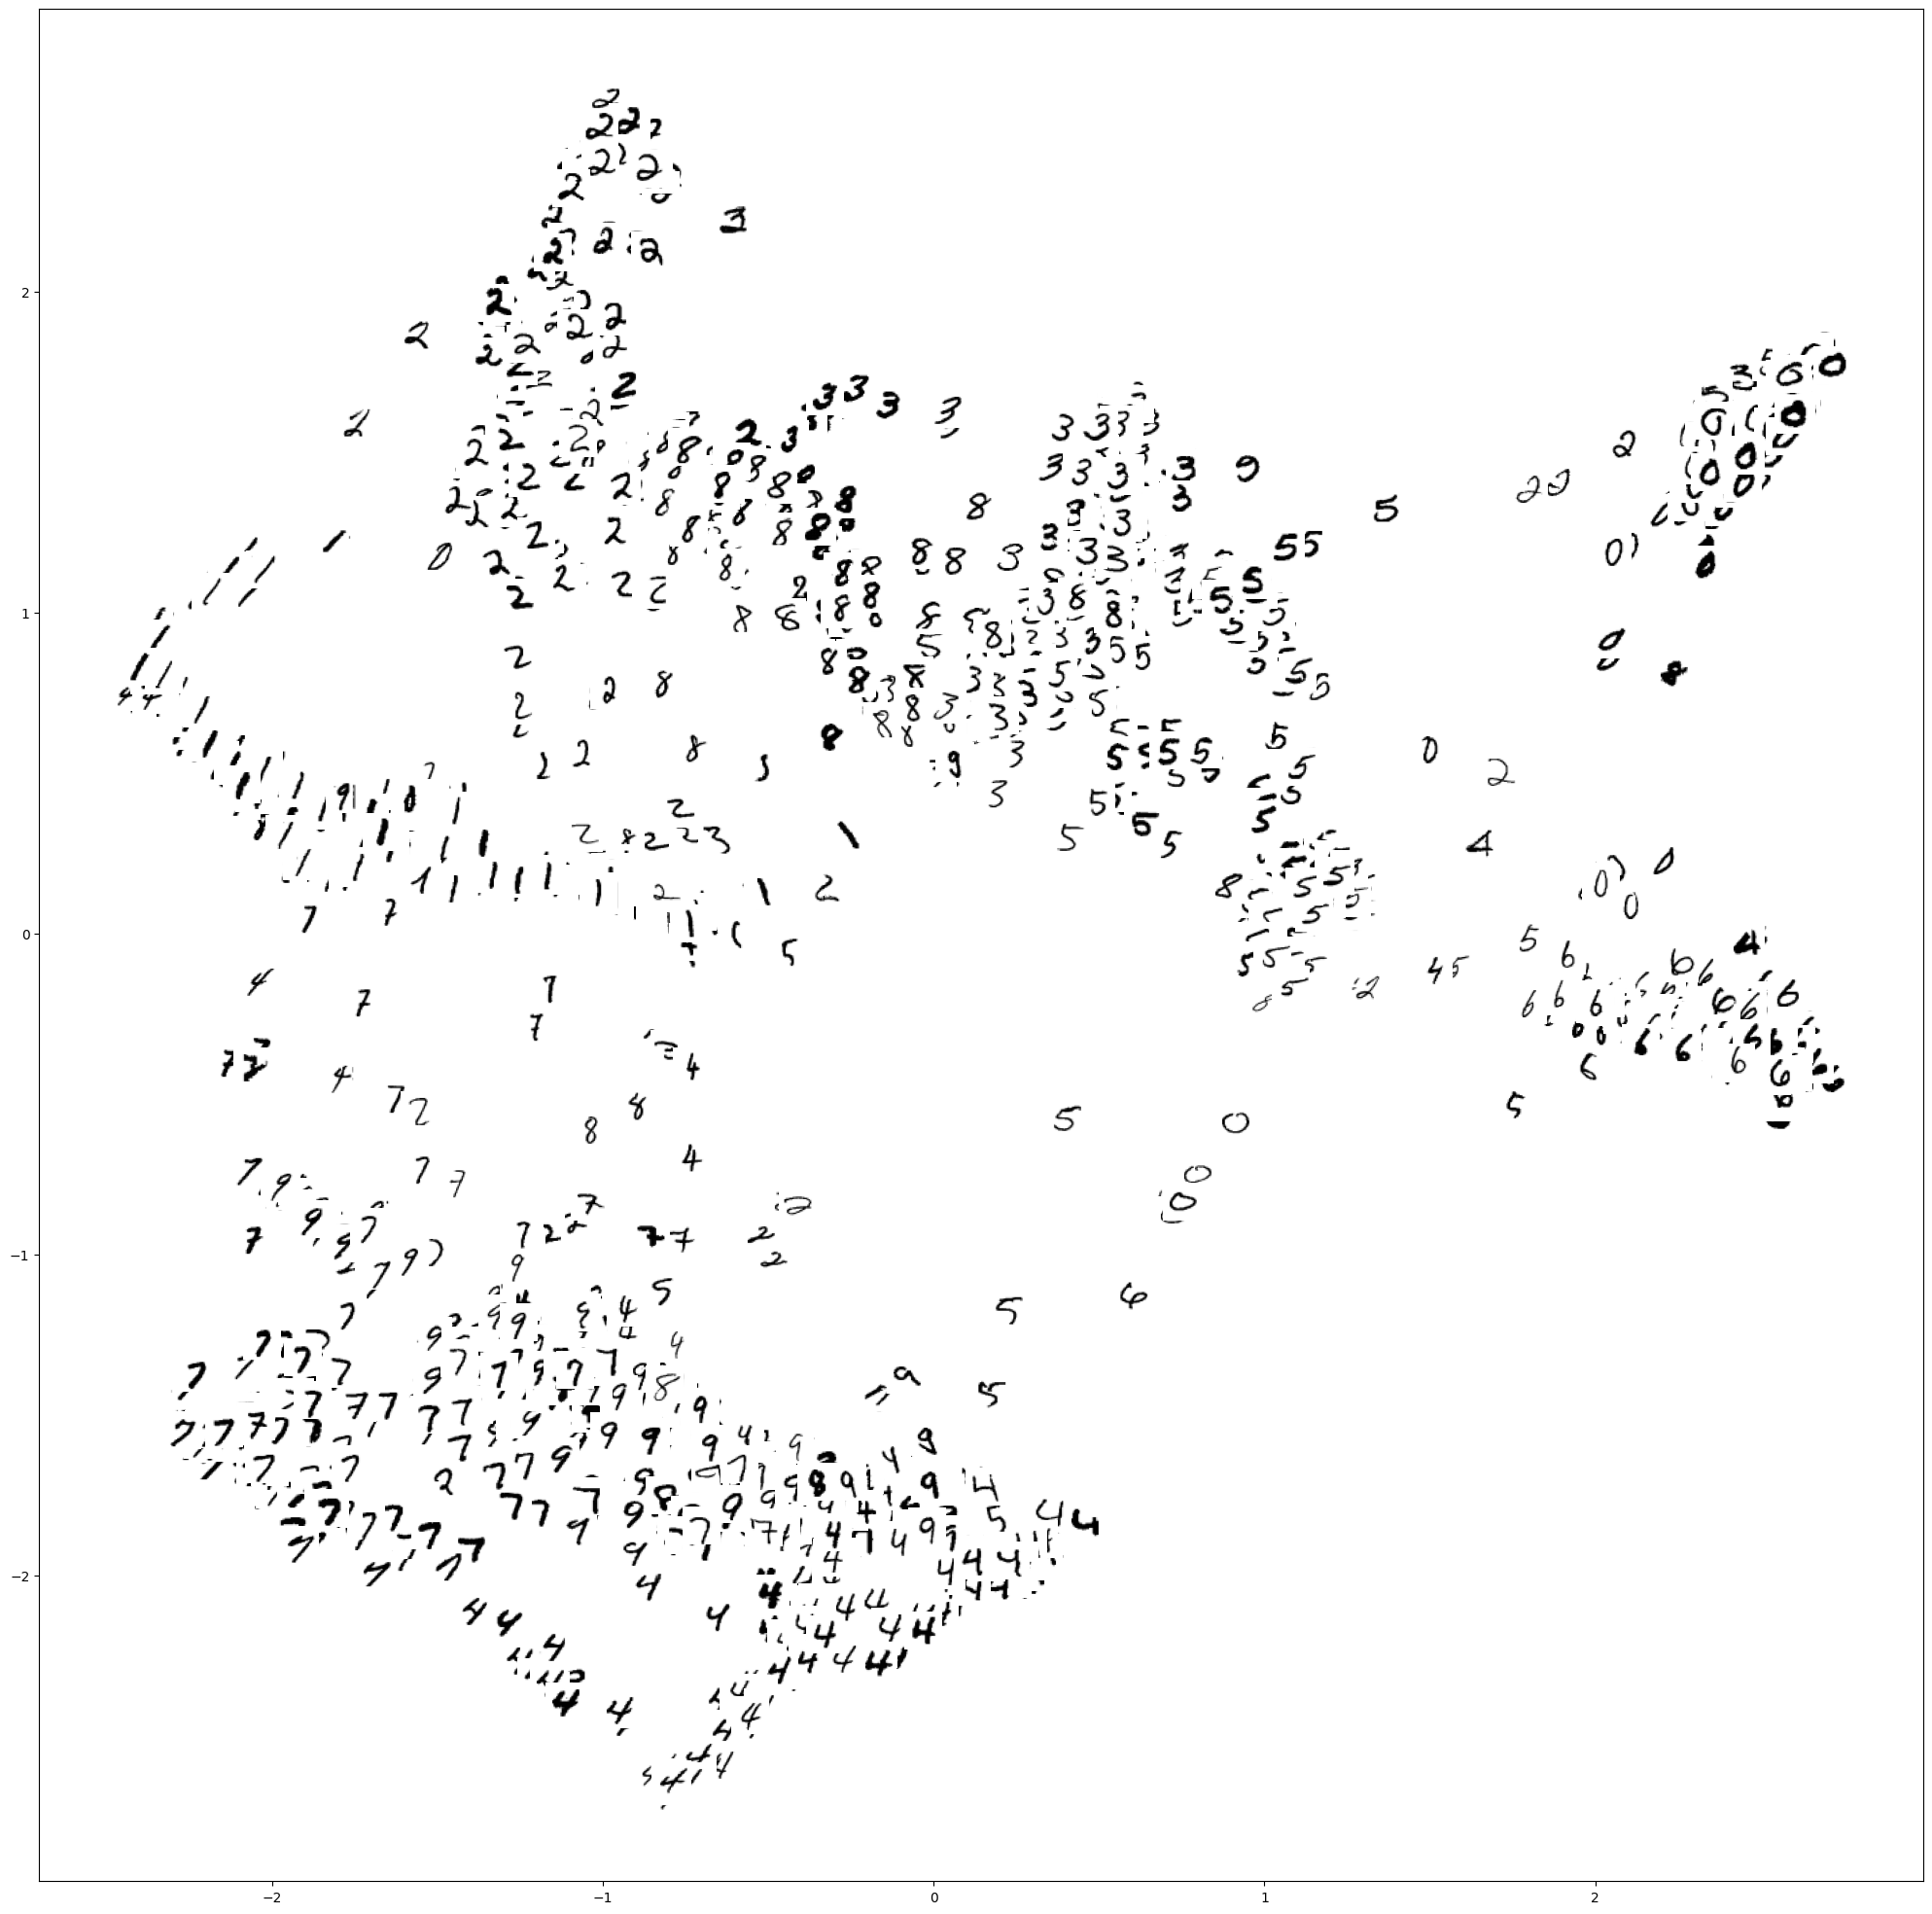

In [67]:
np.random.seed(0)
plt.figure(figsize=(25, 25))  # for larger images!
image_zoom = 1.0  # controls the size of plotted inmages


x_train_img = x_train.reshape(NUM_VECTORS, 28,28)

plt.scatter(x_reduced[:,0], x_reduced[:,1]) # x and y coordinates
for im, xy in zip(x_train_img, x_reduced):
    plot_image_at_point(im, xy, image_zoom)